In [2]:
# result_inspection.py
# GNN Dataset Result Inspection Analysis

import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os
from collections import defaultdict

# Set up paths
BASE_DIR = Path("/root/projects/my-herosim")
DATASETS_DIR = BASE_DIR / "simulation_data/gnn_datasets"
RESULTS_DIR = BASE_DIR / "simulation_data/initial_results_simple"

print(f"Datasets directory: {DATASETS_DIR}")
print(f"Results directory: {RESULTS_DIR}")
print(f"Dataset directories found: {len(list(DATASETS_DIR.glob('ds_*')))}")

Datasets directory: /root/projects/my-herosim/simulation_data/gnn_datasets
Results directory: /root/projects/my-herosim/simulation_data/initial_results_simple
Dataset directories found: 100


Key Features of This Analysis:
- Dataset Structure Analysis: Examines the organization of each dataset (ds_XXXX) and shows what files are present.
- Result File Analysis: Deep dives into the JSON result files to understand the simulation output structure and extract key metrics.
- Configuration Collection: Gathers all configuration parameters across datasets to understand the parameter space being explored.
- Performance Data Collection: Extracts performance metrics (RTT, execution times, cold starts, etc.) from all successful simulations.
- Visualization: Creates plots showing:
    - RTT distribution
    - Parameter impact on performance
    - Correlation matrices
    - Completion progress
- Parameter Impact Analysis: Quantifies how different parameters affect performance through statistical analysis.
- Best Configuration Identification: Finds the top-performing simulations and analyzes their configuration patterns.
- Completion Status: Tracks progress of the dataset generation process.

In [4]:
def analyze_dataset_structure(dataset_id="ds_0030"):
    """Analyze the structure of a specific dataset."""
    dataset_dir = DATASETS_DIR / dataset_id
    
    print(f"=== Dataset {dataset_id} Structure ===")
    
    # Check what files exist
    files = list(dataset_dir.glob("*"))
    print(f"Files in dataset: {[f.name for f in files]}")
    
    # Read results index
    results_index_file = dataset_dir / "results_index.txt"
    if results_index_file.exists():
        with open(results_index_file, 'r') as f:
            result_files = [line.strip() for line in f if line.strip()]
        print(f"\nResult files ({len(result_files)}):")
        for i, file in enumerate(result_files[:5]):  # Show first 5
            print(f"  {i+1}. {file}")
        if len(result_files) > 5:
            print(f"  ... and {len(result_files) - 5} more")
    else:
        print("\nNo results_index.txt found")
    
    # Read configuration
    config_file = dataset_dir / "space_with_network.json"
    if config_file.exists():
        with open(config_file, 'r') as f:
            config = json.load(f)
        
        print(f"\nConfiguration highlights:")
        print(f"  Connection probability: {config['network']['topology']['connection_probability']}")
        print(f"  Client percentage: {config['preinit']['client_percentage']}")
        print(f"  Server percentage: {config['preinit']['server_percentage']}")
        print(f"  DNN1 replicas per server: {config['replicas']['dnn1']['per_server']}")
        print(f"  DNN1 replicas per client: {config['replicas']['dnn1']['per_client']}")
        print(f"  DNN1 initial queue: {config['prewarm']['dnn1']['initial_queue']}")
        print(f"  DNN2 initial queue: {config['prewarm']['dnn2']['initial_queue']}")
    
    return result_files if 'result_files' in locals() else []

# Analyze a few datasets
datasets_to_analyze = ["ds_0030", "ds_0045", "ds_0089"]
for dataset_id in datasets_to_analyze:
    if (DATASETS_DIR / dataset_id).exists():
        analyze_dataset_structure(dataset_id)
        print("\n" + "="*50 + "\n")

=== Dataset ds_0030 Structure ===
Files in dataset: ['space_with_network.json', 'run.log', 'results_index.txt']

Result files (2):
  1. rtt_summary.pdf
  2. simulation_1_placement_cbcd4f83a640057f_34180779.json

Configuration highlights:
  Connection probability: 0.2
  Client percentage: 0.4
  Server percentage: 0.8
  DNN1 replicas per server: 2
  DNN1 replicas per client: 1
  DNN1 initial queue: 24
  DNN2 initial queue: 24


=== Dataset ds_0045 Structure ===
Files in dataset: ['space_with_network.json', 'run.log', 'results_index.txt']

Result files (17):
  1. rtt_summary.pdf
  2. simulation_1_placement_04e701cb7bb0332f_03d8d467.json
  3. simulation_1_placement_04e701cb7bb0332f_46e8be58.json
  4. simulation_1_placement_04e701cb7bb0332f_5cfcd025.json
  5. simulation_1_placement_04e701cb7bb0332f_62b39513.json
  ... and 12 more

Configuration highlights:
  Connection probability: 0.3
  Client percentage: 0.2
  Server percentage: 0.5
  DNN1 replicas per server: 1
  DNN1 replicas per client

In [5]:
def analyze_result_file(result_filename):
    """Analyze the structure of a result JSON file."""
    result_path = RESULTS_DIR / result_filename
    
    if not result_path.exists():
        print(f"Result file not found: {result_filename}")
        return None
    
    with open(result_path, 'r') as f:
        result_data = json.load(f)
    
    print(f"=== Result File: {result_filename} ===")
    print(f"Status: {result_data.get('status', 'unknown')}")
    
    # Analyze top-level structure
    print(f"\nTop-level keys: {list(result_data.keys())}")
    
    # Analyze stats if available
    if 'stats' in result_data:
        stats = result_data['stats']
        print(f"\nStats keys: {list(stats.keys())}")
        
        # Key performance metrics
        print(f"\nKey Performance Metrics:")
        print(f"  End time: {stats.get('endTime', 'N/A')}")
        print(f"  Average elapsed time: {stats.get('averageElapsedTime', 'N/A')}")
        print(f"  Average execution time: {stats.get('averageExecutionTime', 'N/A')}")
        print(f"  Average wait time: {stats.get('averageWaitTime', 'N/A')}")
        print(f"  Average queue time: {stats.get('averageQueueTime', 'N/A')}")
        print(f"  Cold start proportion: {stats.get('coldStartProportion', 'N/A')}")
        print(f"  Penalty proportion: {stats.get('penaltyProportion', 'N/A')}")
        print(f"  Energy: {stats.get('energy', 'N/A')}")
        
        # Task results
        task_results = stats.get('taskResults', [])
        print(f"\nTask Results: {len(task_results)} tasks")
        if task_results:
            print(f"  First task keys: {list(task_results[0].keys())}")
            
            # Calculate total RTT (sum of elapsed times)
            total_rtt = sum(task.get('elapsedTime', 0) for task in task_results)
            print(f"  Total RTT: {total_rtt:.3f}s")
            
            # Task type distribution
            task_types = defaultdict(int)
            for task in task_results:
                task_type = task.get('type', {}).get('name', 'unknown')
                task_types[task_type] += 1
            print(f"  Task type distribution: {dict(task_types)}")
    
    # Analyze sample info if available
    if 'sample' in result_data:
        sample = result_data['sample']
        print(f"\nSample info keys: {list(sample.keys())}")
        if 'placement_plan' in sample:
            placement_plan = sample['placement_plan']
            print(f"  Placement plan: {len(placement_plan)} tasks")
    
    return result_data

# Analyze a specific result file
result_file = "simulation_1_placement_cbcd4f83a640057f_34180779.json"
result_data = analyze_result_file(result_file)


=== Result File: simulation_1_placement_cbcd4f83a640057f_34180779.json ===
Status: success

Top-level keys: ['status', 'config', 'sim_inputs', 'stats', 'sample']

Stats keys: ['policy', 'endTime', 'traceFile', 'unusedPlatforms', 'unusedNodes', 'averageOccupation', 'averageElapsedTime', 'averagePullTime', 'averageColdStartTime', 'averageExecutionTime', 'averageWaitTime', 'averageQueueTime', 'averageInitializationTime', 'averageComputeTime', 'averageCommunicationsTime', 'penaltyProportion', 'localDependenciesProportion', 'localCommunicationsProportion', 'nodeCacheHitsProportion', 'taskCacheHitsProportion', 'coldStartProportion', 'taskResponseTimeDistribution', 'applicationResponseTimeDistribution', 'penaltyDistributionOverTime', 'energy', 'reclaimableEnergy', 'applicationResults', 'nodeResults', 'taskResults', 'scaleEvents', 'systemEvents', 'averageNetworkLatency', 'nodePairLatencies', 'networkTopology', 'offloadingRate', 'systemStateResults']

Key Performance Metrics:
  End time: 4.7251

In [6]:
def collect_dataset_configs():
    """Collect configuration data from all datasets."""
    configs = []
    
    for dataset_dir in sorted(DATASETS_DIR.glob("ds_*")):
        dataset_id = dataset_dir.name
        config_file = dataset_dir / "space_with_network.json"
        
        if config_file.exists():
            try:
                with open(config_file, 'r') as f:
                    config = json.load(f)
                
                # Extract key configuration parameters
                config_info = {
                    'dataset_id': dataset_id,
                    'connection_probability': config['network']['topology']['connection_probability'],
                    'client_percentage': config['preinit']['client_percentage'],
                    'server_percentage': config['preinit']['server_percentage'],
                    'dnn1_per_server': config['replicas']['dnn1']['per_server'],
                    'dnn1_per_client': config['replicas']['dnn1']['per_client'],
                    'dnn2_per_server': config['replicas']['dnn2']['per_server'],
                    'dnn2_per_client': config['replicas']['dnn2']['per_client'],
                    'dnn1_initial_queue': config['prewarm']['dnn1']['initial_queue'],
                    'dnn2_initial_queue': config['prewarm']['dnn2']['initial_queue']
                }
                
                # Check if dataset has results
                results_index_file = dataset_dir / "results_index.txt"
                if results_index_file.exists():
                    with open(results_index_file, 'r') as f:
                        result_files = [line.strip() for line in f if line.strip() and not line.strip().endswith('.pdf')]
                    config_info['has_results'] = len(result_files) > 0
                    config_info['num_results'] = len(result_files)
                else:
                    config_info['has_results'] = False
                    config_info['num_results'] = 0
                
                configs.append(config_info)
                
            except Exception as e:
                print(f"Error reading config for {dataset_id}: {e}")
    
    return pd.DataFrame(configs)

# Collect all configurations
config_df = collect_dataset_configs()
print(f"Collected configurations for {len(config_df)} datasets")
print(f"\nConfiguration summary:")
print(config_df.describe())

# Show unique parameter combinations
print(f"\nUnique parameter combinations:")
param_cols = ['connection_probability', 'client_percentage', 'server_percentage', 
              'dnn1_per_server', 'dnn1_per_client', 'dnn1_initial_queue', 'dnn2_initial_queue']
unique_combos = config_df[param_cols].drop_duplicates()
print(f"Found {len(unique_combos)} unique parameter combinations")
print(unique_combos.head(10))

Collected configurations for 100 datasets

Configuration summary:
       connection_probability  client_percentage  server_percentage  \
count              100.000000         100.000000         100.000000   
mean                 0.300000           0.300000           0.650000   
std                  0.142134           0.100504           0.150756   
min                  0.100000           0.200000           0.500000   
25%                  0.200000           0.200000           0.500000   
50%                  0.300000           0.300000           0.650000   
75%                  0.400000           0.400000           0.800000   
max                  0.500000           0.400000           0.800000   

       dnn1_per_server  dnn1_per_client  dnn2_per_server  dnn2_per_client  \
count       100.000000       100.000000       100.000000       100.000000   
mean          1.500000         0.500000         1.500000         0.500000   
std           0.502519         0.502519         0.502519       

In [7]:
def collect_performance_data():
    """Collect performance data from all result files."""
    performance_data = []
    
    for dataset_dir in sorted(DATASETS_DIR.glob("ds_*")):
        dataset_id = dataset_dir.name
        results_index_file = dataset_dir / "results_index.txt"
        
        if not results_index_file.exists():
            continue
            
        with open(results_index_file, 'r') as f:
            result_files = [line.strip() for line in f if line.strip() and not line.strip().endswith('.pdf')]
        
        # Get configuration for this dataset
        dataset_config = config_df[config_df['dataset_id'] == dataset_id]
        if dataset_config.empty:
            continue
        
        # Analyze each result file for this dataset
        for result_file in result_files:
            result_path = RESULTS_DIR / result_file
            
            if not result_path.exists():
                continue
                
            try:
                with open(result_path, 'r') as f:
                    result_data = json.load(f)
                
                if result_data.get('status') != 'success':
                    continue
                    
                stats = result_data.get('stats', {})
                task_results = stats.get('taskResults', [])
                
                if not task_results:
                    continue
                
                # Calculate total RTT
                total_rtt = sum(task.get('elapsedTime', 0) for task in task_results)
                
                # Extract performance metrics
                perf_info = {
                    'dataset_id': dataset_id,
                    'result_file': result_file,
                    'total_rtt': total_rtt,
                    'num_tasks': len(task_results),
                    'avg_elapsed_time': stats.get('averageElapsedTime', 0),
                    'avg_execution_time': stats.get('averageExecutionTime', 0),
                    'avg_wait_time': stats.get('averageWaitTime', 0),
                    'avg_queue_time': stats.get('averageQueueTime', 0),
                    'cold_start_proportion': stats.get('coldStartProportion', 0),
                    'penalty_proportion': stats.get('penaltyProportion', 0),
                    'energy': stats.get('energy', 0),
                    'end_time': stats.get('endTime', 0)
                }
                
                # Add configuration parameters
                config_row = dataset_config.iloc[0]
                for col in param_cols:
                    perf_info[col] = config_row[col]
                
                performance_data.append(perf_info)
                
            except Exception as e:
                print(f"Error reading {result_file}: {e}")
    
    return pd.DataFrame(performance_data)

# Collect performance data
print("Collecting performance data...")
perf_df = collect_performance_data()
print(f"Collected performance data for {len(perf_df)} simulations")

if len(perf_df) > 0:
    print(f"\nPerformance summary:")
    print(perf_df[['dataset_id', 'total_rtt', 'num_tasks', 'avg_elapsed_time', 'cold_start_proportion']].describe())
    
    # Find best and worst performing simulations
    print(f"\nBest performing simulation (lowest RTT):")
    best_idx = perf_df['total_rtt'].idxmin()
    best_sim = perf_df.loc[best_idx]
    print(f"  Dataset: {best_sim['dataset_id']}")
    print(f"  File: {best_sim['result_file']}")
    print(f"  Total RTT: {best_sim['total_rtt']:.3f}s")
    
    print(f"\nWorst performing simulation (highest RTT):")
    worst_idx = perf_df['total_rtt'].idxmax()
    worst_sim = perf_df.loc[worst_idx]
    print(f"  Dataset: {worst_sim['dataset_id']}")
    print(f"  File: {worst_sim['result_file']}")
    print(f"  Total RTT: {worst_sim['total_rtt']:.3f}s")

Collected performance data for 2485 simulations

Performance summary:
         total_rtt    num_tasks  avg_elapsed_time  cold_start_proportion
count  2485.000000  2485.000000       2485.000000            2485.000000
mean    165.078975   172.584708          0.613662               9.162820
std     278.147825   194.516374          0.405809              15.545888
min       0.850246     5.000000          0.127455               0.413793
25%      10.117569    35.000000          0.321674               1.522843
50%      40.094633   101.000000          0.475510               2.970297
75%     136.987375   197.000000          0.801800               8.571429
max    1097.453520   725.000000          1.513729              60.000000

Best performing simulation (lowest RTT):
  Dataset: ds_0079
  File: simulation_1_placement_db0aefb3fd7de7df_ec5902f6.json
  Total RTT: 0.850s

Worst performing simulation (highest RTT):
  Dataset: ds_0050
  File: simulation_1_placement_153ff931a6b27e18_2a2ed906.json
  Tot

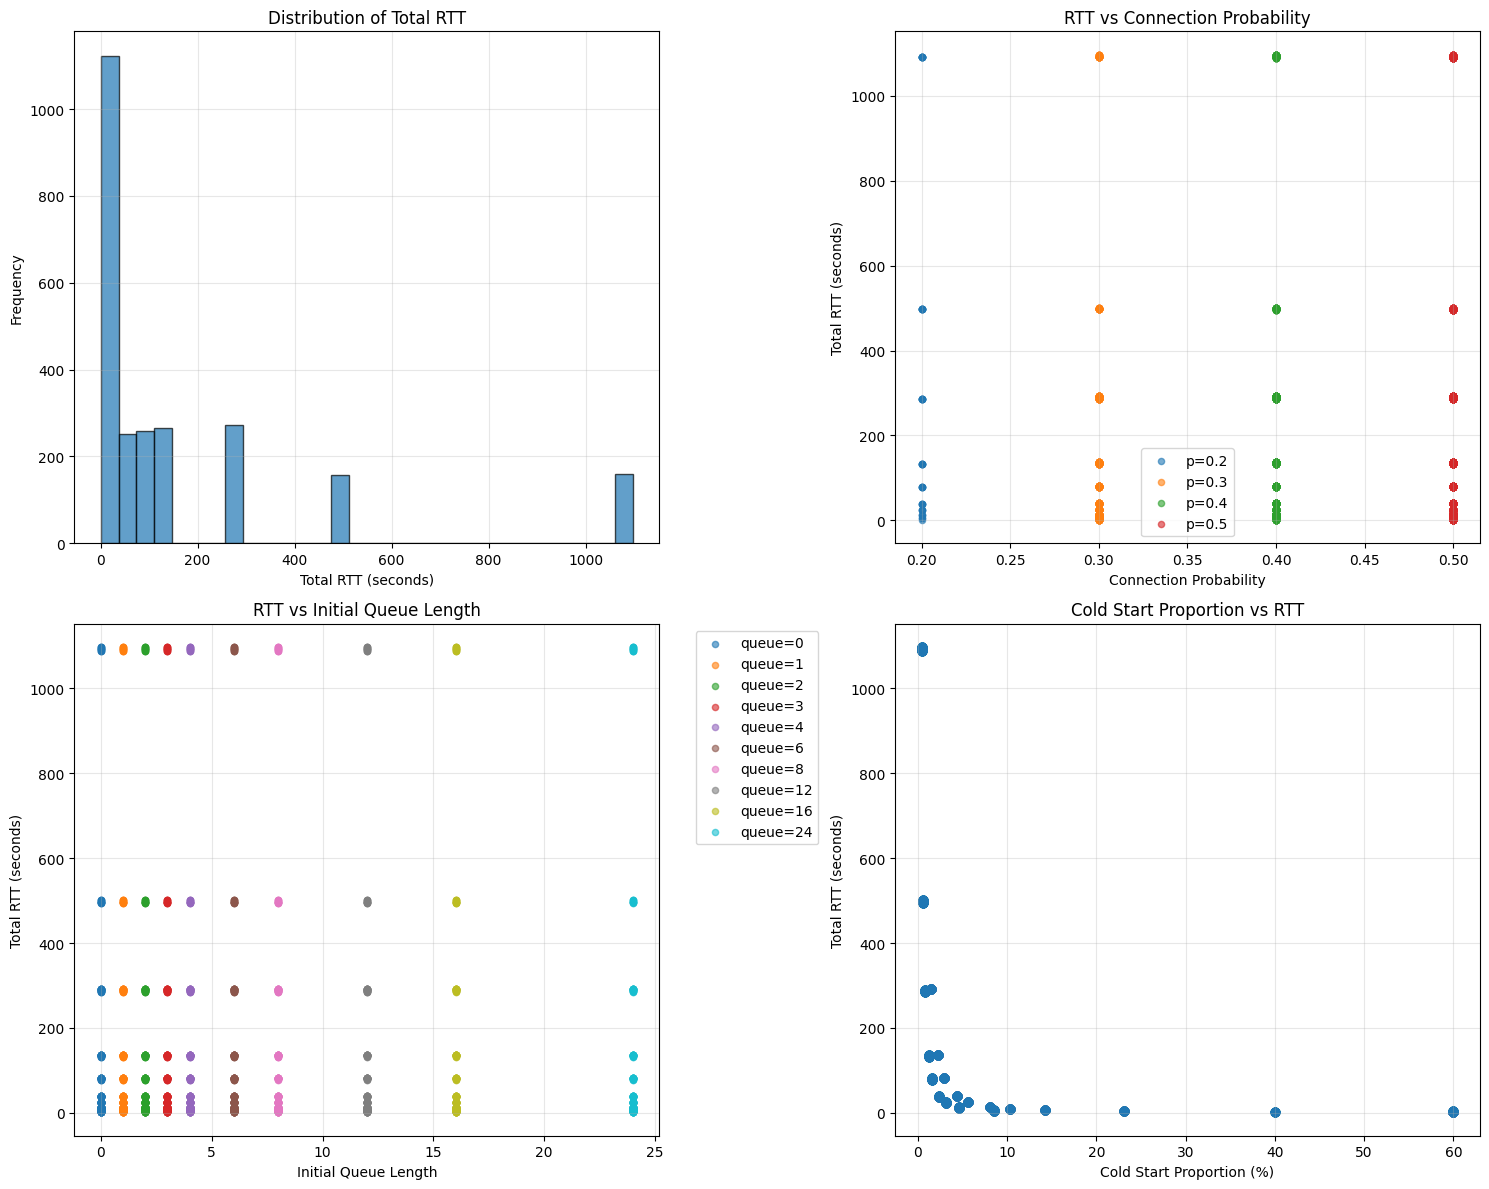


=== Performance Summary ===
Total simulations analyzed: 2485
RTT range: 0.850s - 1097.454s
Average RTT: 165.079s
Median RTT: 40.095s
Standard deviation: 278.148s


In [8]:
if len(perf_df) > 0:
    # Set up the plotting style
    plt.style.use('default')
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # 1. RTT distribution
    axes[0, 0].hist(perf_df['total_rtt'], bins=30, alpha=0.7, edgecolor='black')
    axes[0, 0].set_xlabel('Total RTT (seconds)')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].set_title('Distribution of Total RTT')
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. RTT vs Connection Probability
    connection_probs = perf_df['connection_probability'].unique()
    for prob in sorted(connection_probs):
        subset = perf_df[perf_df['connection_probability'] == prob]
        axes[0, 1].scatter(subset['connection_probability'], subset['total_rtt'], 
                          label=f'p={prob}', alpha=0.6, s=20)
    axes[0, 1].set_xlabel('Connection Probability')
    axes[0, 1].set_ylabel('Total RTT (seconds)')
    axes[0, 1].set_title('RTT vs Connection Probability')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # 3. RTT vs Initial Queue Length
    queue_lengths = perf_df['dnn1_initial_queue'].unique()
    for qlen in sorted(queue_lengths):
        subset = perf_df[perf_df['dnn1_initial_queue'] == qlen]
        axes[1, 0].scatter(subset['dnn1_initial_queue'], subset['total_rtt'], 
                          label=f'queue={qlen}', alpha=0.6, s=20)
    axes[1, 0].set_xlabel('Initial Queue Length')
    axes[1, 0].set_ylabel('Total RTT (seconds)')
    axes[1, 0].set_title('RTT vs Initial Queue Length')
    axes[1, 0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    axes[1, 0].grid(True, alpha=0.3)
    
    # 4. Cold Start Proportion vs RTT
    axes[1, 1].scatter(perf_df['cold_start_proportion'], perf_df['total_rtt'], alpha=0.6)
    axes[1, 1].set_xlabel('Cold Start Proportion (%)')
    axes[1, 1].set_ylabel('Total RTT (seconds)')
    axes[1, 1].set_title('Cold Start Proportion vs RTT')
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Summary statistics
    print("\n=== Performance Summary ===")
    print(f"Total simulations analyzed: {len(perf_df)}")
    print(f"RTT range: {perf_df['total_rtt'].min():.3f}s - {perf_df['total_rtt'].max():.3f}s")
    print(f"Average RTT: {perf_df['total_rtt'].mean():.3f}s")
    print(f"Median RTT: {perf_df['total_rtt'].median():.3f}s")
    print(f"Standard deviation: {perf_df['total_rtt'].std():.3f}s")


=== Parameter Impact on RTT ===

Connection Probability Impact:
                        count        mean         std       min          max
connection_probability                                                      
0.2                        55  353.450485  387.955375  0.984991  1092.699476
0.3                       410  181.797670  291.869719  0.984991  1097.453520
0.4                       810  161.016553  273.996457  0.850246  1097.453520
0.5                      1210  153.571094  267.069949  0.850246  1097.453520

Initial Queue Length Impact:
                    count        mean         std       min         max
dnn1_initial_queue                                                     
0                     280  150.547419  266.779798  0.850246  1097.45352
1                     273  154.355947  269.110990  0.850246  1097.45352
2                     266  158.294792  271.525994  0.850246  1097.45352
3                     259  162.303613  274.068244  0.850246  1097.45352
4           

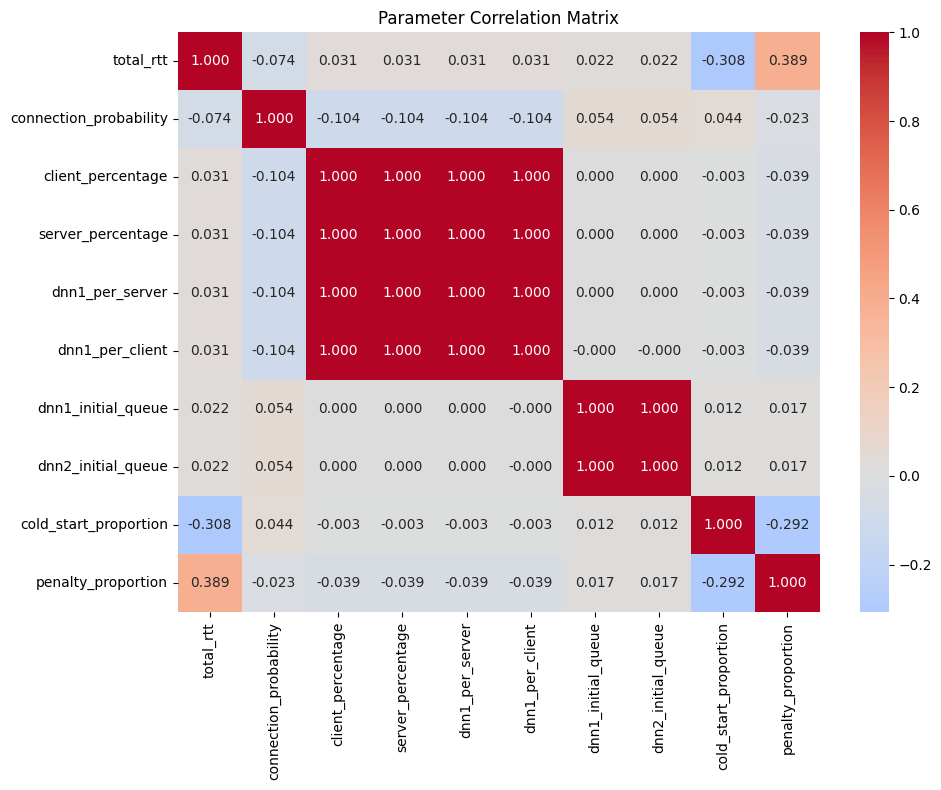


Top correlations with RTT:
  penalty_proportion: 0.389
  cold_start_proportion: 0.308
  connection_probability: 0.074
  dnn1_per_server: 0.031
  client_percentage: 0.031
  dnn1_per_client: 0.031
  server_percentage: 0.031
  dnn2_initial_queue: 0.022
  dnn1_initial_queue: 0.022


In [9]:
if len(perf_df) > 0:
    # Parameter correlation analysis
    print("=== Parameter Impact on RTT ===\n")
    
    # Group by connection probability
    print("Connection Probability Impact:")
    conn_prob_stats = perf_df.groupby('connection_probability')['total_rtt'].agg(['count', 'mean', 'std', 'min', 'max'])
    print(conn_prob_stats)
    
    print("\nInitial Queue Length Impact:")
    queue_stats = perf_df.groupby('dnn1_initial_queue')['total_rtt'].agg(['count', 'mean', 'std', 'min', 'max'])
    print(queue_stats)
    
    print("\nServer Percentage Impact:")
    server_stats = perf_df.groupby('server_percentage')['total_rtt'].agg(['count', 'mean', 'std', 'min', 'max'])
    print(server_stats)
    
    # Correlation matrix
    numeric_cols = ['total_rtt', 'connection_probability', 'client_percentage', 'server_percentage', 
                   'dnn1_per_server', 'dnn1_per_client', 'dnn1_initial_queue', 'dnn2_initial_queue',
                   'cold_start_proportion', 'penalty_proportion']
    
    corr_matrix = perf_df[numeric_cols].corr()
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.3f')
    plt.title('Parameter Correlation Matrix')
    plt.tight_layout()
    plt.show()
    
    # Top correlations with RTT
    rtt_correlations = corr_matrix['total_rtt'].abs().sort_values(ascending=False)
    print(f"\nTop correlations with RTT:")
    for param, corr in rtt_correlations.items():
        if param != 'total_rtt':
            print(f"  {param}: {corr:.3f}")

In [10]:
if len(perf_df) > 0:
    print("=== Top 10 Best Performing Simulations ===\n")
    
    # Get top 10 best performing simulations
    top_10 = perf_df.nsmallest(10, 'total_rtt')
    
    display_cols = ['dataset_id', 'total_rtt', 'connection_probability', 'server_percentage', 
                   'dnn1_initial_queue', 'cold_start_proportion', 'penalty_proportion']
    
    for i, (idx, row) in enumerate(top_10.iterrows(), 1):
        print(f"{i:2d}. Dataset: {row['dataset_id']}")
        print(f"    RTT: {row['total_rtt']:.3f}s")
        print(f"    Connection Prob: {row['connection_probability']}")
        print(f"    Server %: {row['server_percentage']}")
        print(f"    Initial Queue: {row['dnn1_initial_queue']}")
        print(f"    Cold Start %: {row['cold_start_proportion']:.1f}")
        print(f"    Penalty %: {row['penalty_proportion']:.1f}")
        print(f"    Result file: {row['result_file']}")
        print()
    
    # Configuration patterns in top performers
    print("=== Configuration Patterns in Top Performers ===\n")
    
    top_10_config = top_10[['connection_probability', 'server_percentage', 'dnn1_initial_queue']]
    print("Most common values in top 10:")
    for col in top_10_config.columns:
        mode_val = top_10_config[col].mode()
        if len(mode_val) > 0:
            print(f"  {col}: {mode_val[0]} (appears in {sum(top_10_config[col] == mode_val[0])} simulations)")
    
    # Parameter ranges in top performers
    print("\nParameter ranges in top 10:")
    for col in top_10_config.columns:
        min_val = top_10_config[col].min()
        max_val = top_10_config[col].max()
        print(f"  {col}: {min_val} - {max_val}")

=== Top 10 Best Performing Simulations ===

 1. Dataset: ds_0079
    RTT: 0.850s
    Connection Prob: 0.4
    Server %: 0.8
    Initial Queue: 0
    Cold Start %: 60.0
    Penalty %: 0.0
    Result file: simulation_1_placement_db0aefb3fd7de7df_ec5902f6.json

 2. Dataset: ds_0080
    RTT: 0.850s
    Connection Prob: 0.5
    Server %: 0.5
    Initial Queue: 24
    Cold Start %: 60.0
    Penalty %: 0.0
    Result file: simulation_1_placement_db0aefb3fd7de7df_ec5902f6.json

 3. Dataset: ds_0081
    RTT: 0.850s
    Connection Prob: 0.5
    Server %: 0.5
    Initial Queue: 16
    Cold Start %: 60.0
    Penalty %: 0.0
    Result file: simulation_1_placement_db0aefb3fd7de7df_ec5902f6.json

 4. Dataset: ds_0082
    RTT: 0.850s
    Connection Prob: 0.5
    Server %: 0.5
    Initial Queue: 12
    Cold Start %: 60.0
    Penalty %: 0.0
    Result file: simulation_1_placement_db0aefb3fd7de7df_ec5902f6.json

 5. Dataset: ds_0083
    RTT: 0.850s
    Connection Prob: 0.5
    Server %: 0.5
    Initial Q

=== Dataset Completion Status ===

Total datasets: 100
Completed datasets: 70
Completion rate: 70.0%
Total simulations run: 2485
Average simulations per completed dataset: 35.5

Completion by parameter combination:
                                                                                                                                  total_datasets  \
connection_probability client_percentage server_percentage dnn1_per_server dnn1_per_client dnn1_initial_queue dnn2_initial_queue                   
0.1                    0.2               0.5               1               0               0                  0                                1   
                                                                                           1                  1                                1   
                                                                                           2                  2                                1   
                                             

<>:31: SyntaxWarning: invalid escape sequence '\d'
<>:31: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_241835/899874078.py:31: SyntaxWarning: invalid escape sequence '\d'
  config_df['dataset_num'] = config_df['dataset_id'].str.extract('(\d+)').astype(int)


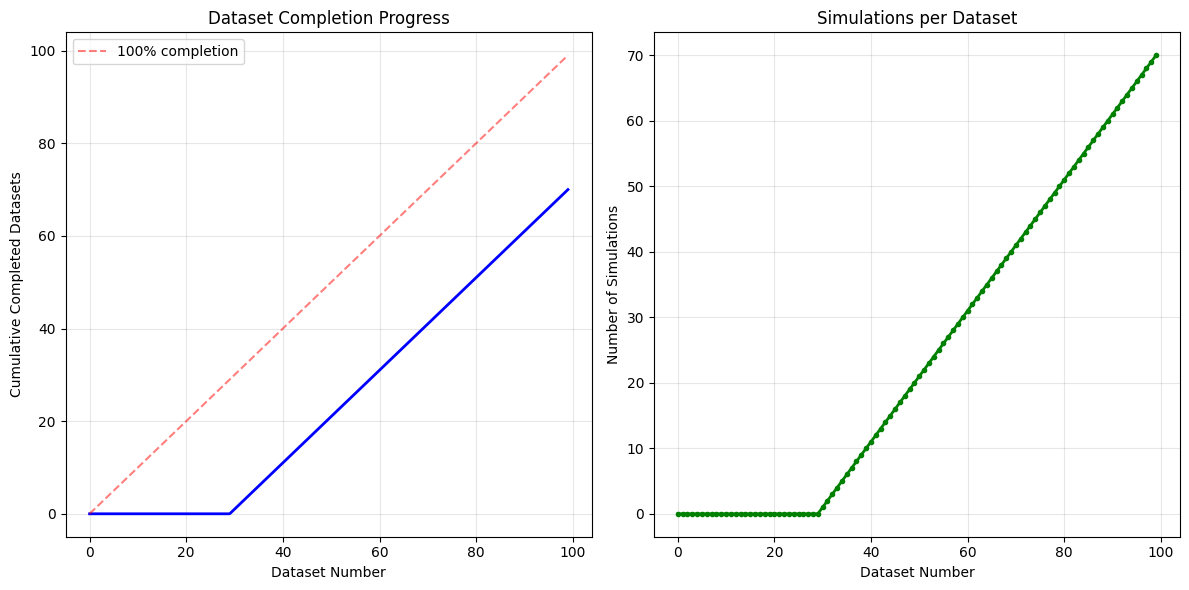

In [11]:
print("=== Dataset Completion Status ===\n")

# Overall completion statistics
total_datasets = len(config_df)
completed_datasets = len(config_df[config_df['has_results'] == True])
total_simulations = config_df['num_results'].sum()

print(f"Total datasets: {total_datasets}")
print(f"Completed datasets: {completed_datasets}")
print(f"Completion rate: {completed_datasets/total_datasets*100:.1f}%")
print(f"Total simulations run: {total_simulations}")

if completed_datasets > 0:
    print(f"Average simulations per completed dataset: {total_simulations/completed_datasets:.1f}")

# Completion by parameter combinations
print("\nCompletion by parameter combination:")
completion_by_params = config_df.groupby(param_cols).agg({
    'dataset_id': 'count',
    'has_results': 'sum',
    'num_results': 'sum'
}).rename(columns={'dataset_id': 'total_datasets', 'has_results': 'completed_datasets'})

completion_by_params['completion_rate'] = completion_by_params['completed_datasets'] / completion_by_params['total_datasets'] * 100

print(completion_by_params.head(10))

# Progress over time (if we have dataset IDs)
if len(config_df) > 0:
    # Extract dataset numbers
    config_df['dataset_num'] = config_df['dataset_id'].str.extract('(\d+)').astype(int)
    
    plt.figure(figsize=(12, 6))
    
    # Plot completion over time
    sorted_config = config_df.sort_values('dataset_num')
    cumulative_completed = sorted_config['has_results'].cumsum()
    
    plt.subplot(1, 2, 1)
    plt.plot(sorted_config['dataset_num'], cumulative_completed, 'b-', linewidth=2)
    plt.plot(sorted_config['dataset_num'], sorted_config['dataset_num'], 'r--', alpha=0.5, label='100% completion')
    plt.xlabel('Dataset Number')
    plt.ylabel('Cumulative Completed Datasets')
    plt.title('Dataset Completion Progress')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot simulations per dataset
    plt.subplot(1, 2, 2)
    plt.plot(sorted_config['dataset_num'], sorted_config['num_results'], 'g-', linewidth=2, marker='o', markersize=3)
    plt.xlabel('Dataset Number')
    plt.ylabel('Number of Simulations')
    plt.title('Simulations per Dataset')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()